# Traceability Graph and Semantic Search for Change Impact Analysis

---



# README

This notebook demonstrates a Change Impact Analysis (CIA) workflow for automotive software engineering artifacts. It combines graph-based traceability analysis with semantic search and reranking techniques to identify engineering artifacts (system requirements, software requirements, components, test cases) that are potentially impacted by a change to a stakeholder requirement.

## Workflow Steps:
1.  **Setup and Imports**: Install necessary libraries and load embedding models.
2.  **Helper Functions**: Define utility functions for graph traversal and evaluation metrics.
3.  **Data Loading**: Load a synthetic automotive engineering dataset.
4.  **Traceability Graph Construction**: Build a directed graph representing traceability links between artifacts.
5.  **Semantic Search Indexing**: Create a FAISS index of artifact embeddings for efficient semantic retrieval.
6.  **Change Request Analysis and Candidate Generation**: Process a change request, generate candidate impacted artifacts using both graph-based and semantic search methods.
7.  **Reranking with Cross-Encoder**: Refine candidate rankings using a cross-encoder model.
8.  **Hybrid Ranking**: Combine semantic, reranker, and graph-based scores into a single hybrid ranking.
9.  **LLM-based Impact Assessment**: Use a Large Language Model (LLM) to perform a final, detailed impact assessment on the top-ranked candidates.
10. **Evaluation**: Evaluate the performance of the different ranking and assessment methods against ground truth data.

# Technical Documentation

## 1. Purpose
This document outlines the technical details of the Change Impact Analysis (CIA) notebook. It serves as a guide for developers, engineers, and stakeholders to understand the system's architecture, components, and usage.

The primary goal of this system is to assist in identifying potentially impacted engineering artifacts when a stakeholder requirement changes, thereby reducing the risk of overlooked impacts and improving the efficiency of the change management process.

## 2. Architecture Overview
The system is implemented as a Jupyter Notebook in Google Colab, leveraging several Python libraries for data processing, graph manipulation, natural language processing (NLP), and machine learning.

### Key Components:
-   **Data Storage**: CSV files containing engineering artifacts and traceability links.
-   **Graph Database (NetworkX)**: In-memory representation of the traceability graph.
-   **Semantic Search (Sentence Transformers & FAISS)**: For embedding artifacts and performing fast similarity searches.
-   **Reranking (Cross-Encoder)**: To improve the relevance of semantically retrieved candidates.
-   **Hybrid Ranking**: A weighted combination of semantic, reranker, and graph-based scores.
-   **Large Language Model (LLM)**: Utilized for detailed, contextual impact assessment of top candidates.
-   **OpenRouter API**: Provides access to various LLM models.
-   **Pydantic**: For defining and validating the LLM's structured output.

### Data Flow:
1.  Raw engineering data (requirements, components, tests, traceability) is loaded from CSV files.
2.  A directed graph (NetworkX) is constructed from the traceability data.
3.  Artifacts are vectorized using a Sentence Transformer model, and these embeddings are indexed with FAISS.
4.  A change request triggers candidate generation via graph traversal and semantic search.
5.  Candidates are reranked using a Cross-Encoder and then merged into a hybrid score.
6.  The top-N candidates are sent to an LLM, along with the change details, for granular impact assessment.
7.  The LLM's structured output (Pydantic models) is parsed and presented.

## 3. Setup and Deployment

### Prerequisites:
-   Google Colab environment.
-   Python 3.x.
-   Access to OpenRouter API (API key required).

### Installation:
All required Python packages are installed at the beginning of the notebook using `pip` commands.

### Configuration:
-   **OPENROUTER_API_KEY**: Must be set as a Colab secret.
-   **MODEL**: The LLM model to be used (e.g., `nvidia/nemotron-3.5-lightning:free`). This can be configured in the notebook.
-   **Dataset**: The `automotive_cia_dataset.zip` file must be uploaded to the Colab environment.

## 4. Usage

### Running the Notebook:
Execute cells sequentially from top to bottom. Key steps involve:
1.  **Data Upload**: Upload the `automotive_cia_dataset.zip` file when prompted.
2.  **Model Initialization**: Wait for embedding and reranker models to load.
3.  **Change Request Selection**: Modify the `change_id` variable to analyze different change requests.
4.  **LLM Interaction**: The LLM call is automated, but its prompt can be inspected in the `user_prompt` variable.

### Interpreting Results:
-   **Hybrid Ranking**: Provides a sorted list of candidates based on combined relevance scores.
-   **LLM Assessments**: Offers a detailed `impact_level` (DIRECT, POTENTIAL, NO_IMPACT), `confidence`, `reason`, and `evidence` for each top candidate, derived from the LLM's analysis.
-   **Evaluation Metrics**: Precision, Recall, and F1-score are used to quantify the effectiveness of retrieval methods at different `k` values against a ground truth.

## Setup and Imports

In [ ]:
!pip -q install pandas networkx sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 19.5 MB/s eta 0:00:00


In [ ]:
# Install necessary libraries
!pip -q install pandas networkx sentence-transformers faiss-cpu scikit-learn

# Import necessary libraries
import os
import json
import pandas as pd
import networkx as nx
import numpy as np
import faiss

from pathlib import Path
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.preprocessing import MinMaxScaler

# Initialize models (these require an internet connection once)
model = SentenceTransformer("all-MiniLM-L6-v2")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("Embedding model loaded.")
print("Reranker loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Embedding model loaded.
Reranker loaded.


In [ ]:
import os
import json
import pandas as pd
import networkx as nx

from pathlib import Path
from sentence_transformers import SentenceTransformer

In [ ]:
print("Python environment is ready.")

print("pandas:", pd.__version__)
print("networkx:", nx.__version__)

Python environment is ready.
pandas: 2.2.3
networkx: 3.6.1


In [ ]:
print("Python environment is ready.")

print("pandas:", pd.__version__)
print("networkx:", nx.__version__)
print("faiss:", faiss.__version__)
# No direct __version__ for sklearn in typical installations, check if present
try:
    import sklearn
    print("scikit-learn:", sklearn.__version__)
except AttributeError:
    print("scikit-learn: Version not readily available")

Python environment is ready.
pandas: 2.2.3
networkx: 3.6.1
faiss: 1.15.0
scikit-learn: 1.6.1


## Helper Functions

In [ ]:
def get_downstream_nodes(graph, start_node):
    """
    Retrieves all downstream nodes (descendants) from a given start node in the graph,
    excluding stakeholder requirements.
    """
    descendants = nx.descendants(graph, start_node)
    return [
        node
        for node in descendants
        if graph.nodes[node].get("type") != "stakeholder_requirement"
    ]

def get_traceability_paths(graph, source, target):
    """
    Finds all simple paths between a source and target node in a graph.
    Limits path length to avoid excessive computation.
    """
    try:
        paths = list(
            nx.all_simple_paths(
                graph,
                source=source,
                target=target,
                cutoff=5 # Limit path length for performance
            )
        )
        return paths
    except nx.NetworkXNoPath:
        return []

def graph_distance(graph, source, target):
    """
    Calculates the shortest path length between two nodes in a graph.
    Returns np.nan if no path exists.
    """
    try:
        return nx.shortest_path_length(
            graph,
            source,
            target
        )
    except nx.NetworkXNoPath:
        return np.nan

def evaluate_at_k(ranked_ids, ground_truth_ids, k):
    """
    Evaluates the precision, recall, and F1-score for a given top-k retrieval.
    """
    retrieved = set(ranked_ids[:k])
    tp = len(retrieved & ground_truth_ids)

    precision = tp / k if k > 0 else 0
    recall = (
        tp / len(ground_truth_ids)
        if ground_truth_ids
        else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    return {
        "k": k,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## Data Loading

In [ ]:
from google.colab import files
import zipfile
from pathlib import Path

uploaded = files.upload()

Saving automotive_cia_dataset.zip to automotive_cia_dataset.zip


In [ ]:
zip_path = next(iter(uploaded.keys()))

extract_dir = Path("/content/automotive_cia_dataset")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:")
print(extract_dir)

Dataset extracted to:
/content/automotive_cia_dataset


In [ ]:
for file in sorted(extract_dir.rglob("*")):
    if file.is_file():
        print(file.relative_to(extract_dir))

README.md
change_requests.csv
components.csv
expected_impacts.csv
metadata.json
requirement_versions.csv
software_requirements.csv
stakeholder_requirements.csv
system_requirements.csv
test_cases.csv
traceability.csv


## Initial Data Overview

In [ ]:
data_dir = extract_dir

stakeholders = pd.read_csv(data_dir / "stakeholder_requirements.csv")
systems = pd.read_csv(data_dir / "system_requirements.csv")
software = pd.read_csv(data_dir / "software_requirements.csv")
components = pd.read_csv(data_dir / "components.csv")
tests = pd.read_csv(data_dir / "test_cases.csv")
traceability = pd.read_csv(data_dir / "traceability.csv")
versions = pd.read_csv(data_dir / "requirement_versions.csv")
changes = pd.read_csv(data_dir / "change_requests.csv")
expected_impacts = pd.read_csv(data_dir / "expected_impacts.csv")

In [ ]:
print("Stakeholder Requirements:", len(stakeholders))
print("System Requirements:", len(systems))
print("Software Requirements:", len(software))
print("Components:", len(components))
print("Test Cases:", len(tests))
print("Traceability Links:", len(traceability))
print("Change Requests:", len(changes))
print("Expected Impacts:", len(expected_impacts))

Stakeholder Requirements: 10
System Requirements: 30
Software Requirements: 30
Components: 14
Test Cases: 19
Traceability Links: 111
Change Requests: 5
Expected Impacts: 25


In [ ]:
changes[changes["change_id"] == "CR-001"].T

,0
change_id,CR-001
change_type,parameter_change
new_text,The vehicle shall detect obstacles within 3 me...
new_version,2
old_text,The vehicle shall detect obstacles within 2 me...
old_version,1
reason,Customer increased obstacle detection range.
requirement_id,SR-001


## Traceability Graph Construction and Analysis

In [ ]:
G = nx.DiGraph()

# Add requirement/artifact nodes
for _, row in stakeholders.iterrows():
    G.add_node(
        row["id"],
        type=row["type"],
        text=row["text"]
    )

for _, row in systems.iterrows():
    G.add_node(
        row["id"],
        type=row["type"],
        text=row["text"]
    )

for _, row in software.iterrows():
    G.add_node(
        row["id"],
        type=row["type"],
        text=row["text"]
    )

for _, row in components.iterrows():
    G.add_node(
        row["id"],
        type=row["type"],
        name=row["name"],
        text=row["description"]
    )

for _, row in tests.iterrows():
    G.add_node(
        row["id"],
        type=row["type"],
        text=row["text"]
    )

# Add traceability edges
for _, row in traceability.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        relation=row["relation"],
        confidence=row["confidence"],
        status=row["status"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 103
Edges: 111


In [ ]:
print("Node types:")

node_types = {}

for _, data in G.nodes(data=True):
    node_type = data.get("type")
    node_types[node_type] = node_types.get(node_type, 0) + 1

for node_type, count in node_types.items():
    print(f"{node_type}: {count}")

Node types:
stakeholder_requirement: 10
system_requirement: 30
software_requirement: 30
component: 14
test_case: 19


In [ ]:
node = "SR-001"

print("Requirement:")
print(G.nodes[node]["text"])

print("\nDirect relationships:")

for target in G.successors(node):
    edge = G[node][target]

    print(
        f"{node} --[{edge['relation']}]--> {target}"
        f" | status={edge['status']}"
        f" | confidence={edge['confidence']}"
    )

Requirement:
The vehicle shall detect obstacles within 2 meters.

Direct relationships:
SR-001 --[satisfied_by]--> SYS-001 | status=valid | confidence=0.98
SR-001 --[satisfied_by]--> SYS-002 | status=valid | confidence=0.98
SR-001 --[satisfied_by]--> SYS-021 | status=valid | confidence=0.98
SR-001 --[satisfied_by]--> SYS-022 | status=valid | confidence=0.98
SR-001 --[satisfied_by]--> SYS-019 | status=invalid | confidence=0.35


In [ ]:
def get_downstream_nodes(graph, start_node):
    descendants = nx.descendants(graph, start_node)

    return [
        node
        for node in descendants
        if graph.nodes[node].get("type") != "stakeholder_requirement"
    ]

In [ ]:
candidates = get_downstream_nodes(G, "SR-001")

print("Downstream candidates:")
for node in candidates:
    print(
        node,
        "|",
        G.nodes[node].get("type"),
        "|",
        G.nodes[node].get("text", G.nodes[node].get("name"))
    )

Downstream candidates:
TC-013 | test_case | Verify obstacle processing executes every 50 milliseconds.
TC-001 | test_case | Verify obstacle detection at 2 meters.
SYS-022 | system_requirement | The obstacle detection system shall reject obstacle measurements with invalid sensor quality flags.
SYS-002 | system_requirement | The obstacle detection system shall publish obstacle distance measurements to the vehicle controller.
SWR-021 | software_requirement | The obstacle processing task shall execute every 50 milliseconds.
SWR-019 | software_requirement | The lane estimator shall calculate lateral distance to lane boundaries.
SYS-019 | system_requirement | The lane monitoring system shall determine the vehicle position relative to lane boundaries.
SYS-001 | system_requirement | The obstacle detection system shall detect objects at distances up to 2 meters.
SWR-001 | software_requirement | The obstacle detector shall classify an obstacle as detected when distance <= 2 meters.
SYS-021 | sys

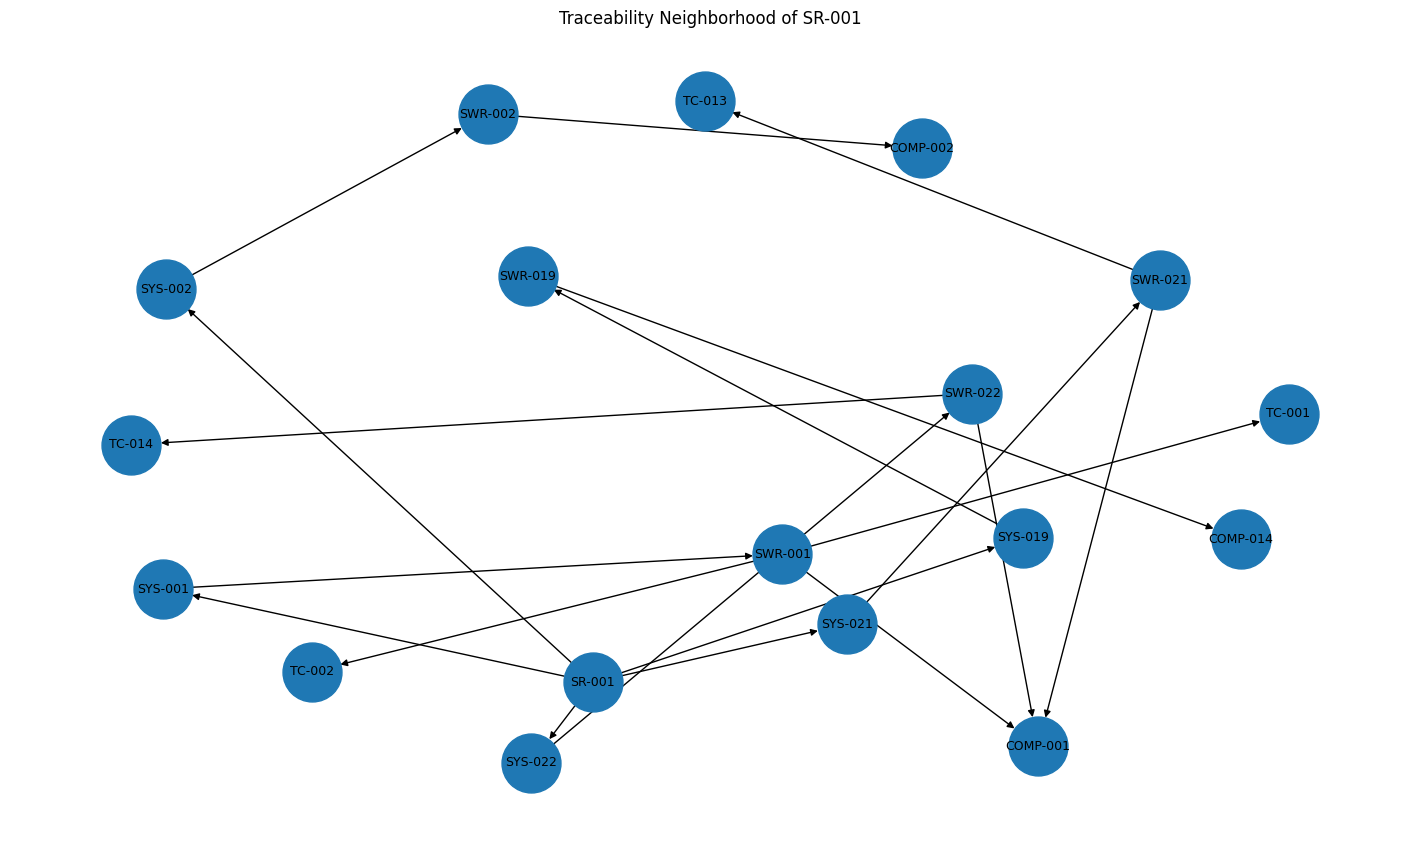

In [ ]:
import matplotlib.pyplot as plt

start_node = "SR-001"

nodes_to_draw = {start_node}

for node in nx.descendants(G, start_node):
    nodes_to_draw.add(node)

subgraph = G.subgraph(nodes_to_draw)

plt.figure(figsize=(14, 8))

pos = nx.spring_layout(
    subgraph,
    seed=42,
    k=1.5
)

nx.draw(
    subgraph,
    pos,
    with_labels=True,
    node_size=1800,
    font_size=9,
    arrows=True
)

plt.title("Traceability Neighborhood of SR-001")
plt.show()

## Semantic Search Indexing

In [ ]:
artifact_records = []

def add_artifacts(df, artifact_type, text_column="text"):
    for _, row in df.iterrows():
        artifact_records.append({
            "id": row["id"],
            "type": artifact_type,
            "text": row[text_column]
        })

add_artifacts(systems, "system_requirement")
add_artifacts(software, "software_requirement")
add_artifacts(components, "component", "description")
add_artifacts(tests, "test_case")

artifacts_df = pd.DataFrame(artifact_records)

print("Total searchable artifacts:", len(artifacts_df))
artifacts_df.head()

Total searchable artifacts: 93


,id,type,text
0,SYS-001,system_requirement,The obstacle detection system shall detect obj...
1,SYS-002,system_requirement,The obstacle detection system shall publish ob...
2,SYS-003,system_requirement,The lighting controller shall measure ambient ...
3,SYS-004,system_requirement,The lighting controller shall activate the hea...
4,SYS-005,system_requirement,The tire pressure monitoring system shall acqu...


In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded.


In [ ]:
artifact_embeddings = model.encode(
    artifacts_df["text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

print("Embedding shape:", artifact_embeddings.shape)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding shape: (93, 384)


In [ ]:
import faiss
import numpy as np

dimension = artifact_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(
    np.asarray(artifact_embeddings, dtype="float32")
)

print("FAISS index size:", index.ntotal)

FAISS index size: 93


In [ ]:
def semantic_retrieve(query, top_k=10):
    query_embedding = model.encode(
        [query],
        normalize_embeddings=True
    )

    scores, indices = index.search(
        np.asarray(query_embedding, dtype="float32"),
        top_k
    )

    results = artifacts_df.iloc[indices[0]].copy()

    results["similarity"] = scores[0]

    return results.reset_index(drop=True)

## Change Request Analysis and Candidate Generation

In [ ]:
changed_sr = stakeholders[
    stakeholders["id"] == "SR-001"
].iloc[0]

query = changed_sr["text"]

print("Query:")
print(query)

retrieved = semantic_retrieve(
    query,
    top_k=10
)

retrieved

Query:
The vehicle shall detect obstacles within 2 meters.


,id,type,text,similarity
0,SYS-001,system_requirement,The obstacle detection system shall detect obj...,0.826862
1,SWR-001,software_requirement,The obstacle detector shall classify an obstac...,0.790369
2,TC-001,test_case,Verify obstacle detection at 2 meters.,0.778970
3,SYS-007,system_requirement,The parking assistance system shall detect obs...,0.758896
4,SYS-002,system_requirement,The obstacle detection system shall publish ob...,0.714232
5,TC-006,test_case,Verify parking obstacles are detected at 1.5 m...,0.702558
6,COMP-006,component,Detects obstacles during parking maneuvers.,0.637219
7,SYS-021,system_requirement,The obstacle detection system shall process se...,0.620185
8,SWR-002,software_requirement,The obstacle processing task shall publish obs...,0.609095
9,COMP-002,component,Publishes obstacle distance measurements.,0.606609


In [ ]:
change = changes[
    changes["change_id"] == "CR-001"
].iloc[0]

old_text = change["old_text"]
new_text = change["new_text"]

print("OLD:")
print(old_text)

print("\nNEW:")
print(new_text)

print("\nCHANGE TYPE:")
print(change["change_type"])

print("\nREASON:")
print(change["reason"])

OLD:
The vehicle shall detect obstacles within 2 meters.

NEW:
The vehicle shall detect obstacles within 3 meters.

CHANGE TYPE:
parameter_change

REASON:
Customer increased obstacle detection range.


In [ ]:
# Construct a query reflecting the change for semantic search
change_query = f"""
Changed stakeholder requirement:

OLD:
{old_text}

NEW:
{new_text}

Change type:
{change['change_type']}

Reason:
{change['reason']}

Find engineering artifacts that may be affected by this change.
""".strip()

print("Change Query for Semantic Search:")
print(change_query)


Change Query for Semantic Search:
Changed stakeholder requirement:

OLD:
The vehicle shall detect obstacles within 2 meters.

NEW:
The vehicle shall detect obstacles within 3 meters.

Change type:
parameter_change

Reason:
Customer increased obstacle detection range.

Find engineering artifacts that may be affected by this change.


In [ ]:
change_retrieved = semantic_retrieve(
    change_query,
    top_k=15
)

change_retrieved

,id,type,text,similarity
0,SWR-001,software_requirement,The obstacle detector shall classify an obstac...,0.686427
1,SYS-001,system_requirement,The obstacle detection system shall detect obj...,0.675158
2,TC-001,test_case,Verify obstacle detection at 2 meters.,0.645372
3,SYS-007,system_requirement,The parking assistance system shall detect obs...,0.622161
4,SYS-002,system_requirement,The obstacle detection system shall publish ob...,0.595509
5,TC-006,test_case,Verify parking obstacles are detected at 1.5 m...,0.577892
6,SWR-002,software_requirement,The obstacle processing task shall publish obs...,0.549519
7,SYS-022,system_requirement,The obstacle detection system shall reject obs...,0.541823
8,COMP-002,component,Publishes obstacle distance measurements.,0.535015
9,SWR-008,software_requirement,The parking warning task shall publish obstacl...,0.519801


In [ ]:
graph_candidates = get_downstream_nodes(
    G,
    "SR-001"
)

print("Graph candidates:")
print(graph_candidates)

Graph candidates:
['TC-013', 'TC-001', 'SYS-022', 'SYS-002', 'SWR-021', 'SWR-019', 'SYS-019', 'SYS-001', 'SWR-001', 'SYS-021', 'COMP-001', 'TC-002', 'COMP-002', 'TC-014', 'COMP-014', 'SWR-002', 'SWR-022']


In [ ]:
retrieval_candidates = change_retrieved["id"].tolist()

print("Retrieval candidates:")
print(retrieval_candidates)

Retrieval candidates:
['SWR-001', 'SYS-001', 'TC-001', 'SYS-007', 'SYS-002', 'TC-006', 'SWR-002', 'SYS-022', 'COMP-002', 'SWR-008', 'SYS-021', 'TC-002', 'SYS-008', 'SWR-007', 'COMP-006']


In [ ]:
candidate_ids = list(
    dict.fromkeys(
        graph_candidates + retrieval_candidates
    )
)

print("Combined candidate count:", len(candidate_ids))

print(candidate_ids)

Combined candidate count: 23
['TC-013', 'TC-001', 'SYS-022', 'SYS-002', 'SWR-021', 'SWR-019', 'SYS-019', 'SYS-001', 'SWR-001', 'SYS-021', 'COMP-001', 'TC-002', 'COMP-002', 'TC-014', 'COMP-014', 'SWR-002', 'SWR-022', 'SYS-007', 'TC-006', 'SWR-008', 'SYS-008', 'SWR-007', 'COMP-006']


In [ ]:
candidate_records = []

retrieval_scores = dict(
    zip(
        change_retrieved["id"],
        change_retrieved["similarity"]
    )
)

for artifact_id in candidate_ids:
    node_data = G.nodes[artifact_id]

    paths = get_traceability_paths(
        G,
        "SR-001",
        artifact_id
    )

    # Calculate graph distance and linked status
    current_graph_distance = graph_distance(G, "SR-001", artifact_id)
    current_graph_linked = artifact_id in graph_candidates

    candidate_records.append({
        "id": artifact_id,
        "type": node_data.get("type"),
        "text": node_data.get(
            "text",
            node_data.get("name", "")
        ),
        "semantic_similarity": retrieval_scores.get(
            artifact_id,
            np.nan
        ),
        "graph_linked": current_graph_linked,
        "graph_distance": current_graph_distance,
        "paths": paths
    })

candidate_df = pd.DataFrame(candidate_records)

candidate_df["graph_linked_numeric"] = (
    candidate_df["graph_linked"].astype(int)
)

display(candidate_df.head())

,id,type,text,semantic_similarity,graph_linked,graph_distance,paths,graph_linked_numeric
0,TC-013,test_case,Verify obstacle processing executes every 50 m...,NaN,True,3.0,"[[SR-001, SYS-021, SWR-021, TC-013]]",1
1,TC-001,test_case,Verify obstacle detection at 2 meters.,0.645372,True,3.0,"[[SR-001, SYS-001, SWR-001, TC-001]]",1
2,SYS-022,system_requirement,The obstacle detection system shall reject obs...,0.541823,True,1.0,"[[SR-001, SYS-022]]",1
3,SYS-002,system_requirement,The obstacle detection system shall publish ob...,0.595509,True,1.0,"[[SR-001, SYS-002]]",1
4,SWR-021,software_requirement,The obstacle processing task shall execute eve...,NaN,True,2.0,"[[SR-001, SYS-021, SWR-021]]",1


## Reranking with Cross-Encoder

In [ ]:
def get_traceability_paths(graph, source, target):
    try:
        paths = list(
            nx.all_simple_paths(
                graph,
                source=source,
                target=target,
                cutoff=5
            )
        )
        return paths
    except nx.NetworkXNoPath:
        return []

In [ ]:
candidate_records = []

retrieval_scores = dict(
    zip(
        change_retrieved["id"],
        change_retrieved["similarity"]
    )
)

for artifact_id in candidate_ids:

    node_data = G.nodes[artifact_id]

    paths = get_traceability_paths(
        G,
        "SR-001",
        artifact_id
    )

    candidate_records.append({
        "id": artifact_id,
        "type": node_data.get("type"),
        "text": node_data.get(
            "text",
            node_data.get("name", "")
        ),
        "semantic_similarity": retrieval_scores.get(
            artifact_id,
            np.nan
        ),
        "graph_linked": artifact_id in graph_candidates,
        "paths": paths
    })

candidate_df = pd.DataFrame(candidate_records)

candidate_df

,id,type,text,semantic_similarity,graph_linked,paths
0,TC-013,test_case,Verify obstacle processing executes every 50 m...,NaN,True,"[[SR-001, SYS-021, SWR-021, TC-013]]"
1,TC-001,test_case,Verify obstacle detection at 2 meters.,0.645372,True,"[[SR-001, SYS-001, SWR-001, TC-001]]"
2,SYS-022,system_requirement,The obstacle detection system shall reject obs...,0.541823,True,"[[SR-001, SYS-022]]"
3,SYS-002,system_requirement,The obstacle detection system shall publish ob...,0.595509,True,"[[SR-001, SYS-002]]"
4,SWR-021,software_requirement,The obstacle processing task shall execute eve...,NaN,True,"[[SR-001, SYS-021, SWR-021]]"
5,SWR-019,software_requirement,The lane estimator shall calculate lateral dis...,NaN,True,"[[SR-001, SYS-019, SWR-019]]"
6,SYS-019,system_requirement,The lane monitoring system shall determine the...,NaN,True,"[[SR-001, SYS-019]]"
7,SYS-001,system_requirement,The obstacle detection system shall detect obj...,0.675158,True,"[[SR-001, SYS-001]]"
8,SWR-001,software_requirement,The obstacle detector shall classify an obstac...,0.686427,True,"[[SR-001, SYS-001, SWR-001]]"
9,SYS-021,system_requirement,The obstacle detection system shall process se...,0.505180,True,"[[SR-001, SYS-021]]"


In [ ]:
candidate_df[
    [
        "id",
        "type",
        "semantic_similarity",
        "graph_linked",
        "text"
    ]
].sort_values(
    "semantic_similarity",
    ascending=False
)

,id,type,semantic_similarity,graph_linked,text
8,SWR-001,software_requirement,0.686427,True,The obstacle detector shall classify an obstac...
7,SYS-001,system_requirement,0.675158,True,The obstacle detection system shall detect obj...
1,TC-001,test_case,0.645372,True,Verify obstacle detection at 2 meters.
17,SYS-007,system_requirement,0.622161,False,The parking assistance system shall detect obs...
3,SYS-002,system_requirement,0.595509,True,The obstacle detection system shall publish ob...
18,TC-006,test_case,0.577892,False,Verify parking obstacles are detected at 1.5 m...
15,SWR-002,software_requirement,0.549519,True,The obstacle processing task shall publish obs...
2,SYS-022,system_requirement,0.541823,True,The obstacle detection system shall reject obs...
12,COMP-002,component,0.535015,True,Publishes obstacle distance measurements.
19,SWR-008,software_requirement,0.519801,False,The parking warning task shall publish obstacl...


In [ ]:
candidate_df["graph_distance"] = candidate_df["id"].apply(
    lambda x: nx.shortest_path_length(G, "SR-001", x)
    if nx.has_path(G, "SR-001", x)
    else np.nan
)

In [ ]:
candidate_df[
    [
        "id",
        "type",
        "semantic_similarity",
        "graph_linked",
        "graph_distance",
        "text"
    ]
].sort_values(
    "semantic_similarity",
    ascending=False
)

,id,type,semantic_similarity,graph_linked,graph_distance,text
8,SWR-001,software_requirement,0.686427,True,2.0,The obstacle detector shall classify an obstac...
7,SYS-001,system_requirement,0.675158,True,1.0,The obstacle detection system shall detect obj...
1,TC-001,test_case,0.645372,True,3.0,Verify obstacle detection at 2 meters.
17,SYS-007,system_requirement,0.622161,False,NaN,The parking assistance system shall detect obs...
3,SYS-002,system_requirement,0.595509,True,1.0,The obstacle detection system shall publish ob...
18,TC-006,test_case,0.577892,False,NaN,Verify parking obstacles are detected at 1.5 m...
15,SWR-002,software_requirement,0.549519,True,2.0,The obstacle processing task shall publish obs...
2,SYS-022,system_requirement,0.541823,True,1.0,The obstacle detection system shall reject obs...
12,COMP-002,component,0.535015,True,3.0,Publishes obstacle distance measurements.
19,SWR-008,software_requirement,0.519801,False,NaN,The parking warning task shall publish obstacl...


In [ ]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

print("Reranker loaded.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Reranker loaded.


In [ ]:
rerank_query = f"""
A stakeholder requirement changed.

OLD:
{old_text}

NEW:
{new_text}

Change type:
{change['change_type']}

Determine whether the engineering artifact below is relevant
to assessing the impact of this change.
""".strip()

print(rerank_query)

A stakeholder requirement changed.

OLD:
The vehicle shall detect obstacles within 2 meters.

NEW:
The vehicle shall detect obstacles within 3 meters.

Change type:
parameter_change

Determine whether the engineering artifact below is relevant
to assessing the impact of this change.


In [ ]:
pairs = [
    (
        rerank_query,
        row["text"]
    )
    for _, row in candidate_df.iterrows()
]

In [ ]:
reranker_scores = reranker.predict(
    pairs,
    show_progress_bar=True
)

candidate_df["reranker_score"] = reranker_scores

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

## Hybrid Ranking

In [ ]:
reranked = candidate_df.sort_values(
    "reranker_score",
    ascending=False
).reset_index(drop=True)

reranked[
    [
        "id",
        "type",
        "semantic_similarity",
        "reranker_score",
        "graph_linked",
        "text"
    ]
]

,id,type,semantic_similarity,reranker_score,graph_linked,text
0,SYS-001,system_requirement,0.675158,1.899400,True,The obstacle detection system shall detect obj...
1,SYS-007,system_requirement,0.622161,1.691282,False,The parking assistance system shall detect obs...
2,SWR-001,software_requirement,0.686427,1.467880,True,The obstacle detector shall classify an obstac...
3,TC-001,test_case,0.645372,0.945338,True,Verify obstacle detection at 2 meters.
4,TC-006,test_case,0.577892,-0.120620,False,Verify parking obstacles are detected at 1.5 m...
5,SYS-002,system_requirement,0.595509,-0.294199,True,The obstacle detection system shall publish ob...
6,SYS-022,system_requirement,0.541823,-1.387940,True,The obstacle detection system shall reject obs...
7,COMP-006,component,0.468324,-1.512583,False,Detects obstacles during parking maneuvers.
8,SYS-021,system_requirement,0.505180,-1.605444,True,The obstacle detection system shall process se...
9,TC-002,test_case,0.502774,-1.808048,True,Verify obstacles beyond the configured detecti...


In [ ]:
top_k = 10

top_candidates = reranked.head(top_k)

for _, row in top_candidates.iterrows():

    print("=" * 80)

    print(
        f"{row['id']} | "
        f"{row['type']} | "
        f"reranker={row['reranker_score']:.4f} | "
        f"similarity={row['semantic_similarity']}"
    )

    print(row["text"])

SYS-001 | system_requirement | reranker=1.8994 | similarity=0.6751578450202942
The obstacle detection system shall detect objects at distances up to 2 meters.
SYS-007 | system_requirement | reranker=1.6913 | similarity=0.622160792350769
The parking assistance system shall detect obstacles at distances up to 1.5 meters.
SWR-001 | software_requirement | reranker=1.4679 | similarity=0.6864265203475952
The obstacle detector shall classify an obstacle as detected when distance <= 2 meters.
TC-001 | test_case | reranker=0.9453 | similarity=0.645371675491333
Verify obstacle detection at 2 meters.
TC-006 | test_case | reranker=-0.1206 | similarity=0.5778921842575073
Verify parking obstacles are detected at 1.5 meters.
SYS-002 | system_requirement | reranker=-0.2942 | similarity=0.5955085158348083
The obstacle detection system shall publish obstacle distance measurements to the vehicle controller.
SYS-022 | system_requirement | reranker=-1.3879 | similarity=0.5418230295181274
The obstacle detec

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

reranked["reranker_score_norm"] = scaler.fit_transform(
    reranked[["reranker_score"]]
)

In [ ]:
reranked[
    [
        "id",
        "semantic_similarity",
        "reranker_score",
        "reranker_score_norm",
        "graph_linked"
    ]
].head(10)

,id,semantic_similarity,reranker_score,reranker_score_norm,graph_linked
0,SYS-001,0.675158,1.899400,1.000000,True
1,SYS-007,0.622161,1.691282,0.970796,False
2,SWR-001,0.686427,1.467880,0.939447,True
3,TC-001,0.645372,0.945338,0.866120,True
4,TC-006,0.577892,-0.120620,0.716539,False
5,SYS-002,0.595509,-0.294199,0.692181,True
6,SYS-022,0.541823,-1.387940,0.538701,True
7,COMP-006,0.468324,-1.512583,0.521210,False
8,SYS-021,0.505180,-1.605444,0.508179,True
9,TC-002,0.502774,-1.808048,0.479749,True


In [ ]:
def graph_distance(graph, source, target):
    try:
        return nx.shortest_path_length(
            graph,
            source,
            target
        )
    except nx.NetworkXNoPath:
        return np.nan


candidate_df["graph_distance"] = candidate_df["id"].apply(
    lambda x: graph_distance(G, "SR-001", x)
)

candidate_df["graph_linked_numeric"] = (
    candidate_df["graph_linked"].astype(int)
)

In [ ]:
expected_impacts.head(20)

,artifact_id,change_id,expected_impact,reason
0,SYS-001,CR-001,high,Detection range changes from 2m to 3m; system ...
1,SWR-001,CR-001,high,Software classification threshold is explicitl...
2,COMP-001,CR-001,high,Obstacle detector implements the changed detec...
3,TC-001,CR-001,high,Test explicitly verifies detection at 2m and s...
4,TC-002,CR-001,medium,Test boundary depends on the configured detect...
5,SYS-021,CR-001,medium,Processing behavior may need review as increas...
6,SYS-022,CR-001,low,Sensor-quality filtering is adjacent to the ch...
7,SYS-025,CR-001,potential,No explicit link exists; semantic relation sug...
8,SYS-004,CR-002,high,System requirement explicitly contains the 100...
9,SWR-004,CR-002,high,Software condition explicitly uses 100 lux.


In [ ]:
expected_impacts.columns.tolist()

['artifact_id', 'change_id', 'expected_impact', 'reason']

In [ ]:
cr1_ground_truth = expected_impacts[
    expected_impacts["change_id"] == "CR-001"
]

cr1_ground_truth

,artifact_id,change_id,expected_impact,reason
0,SYS-001,CR-001,high,Detection range changes from 2m to 3m; system ...
1,SWR-001,CR-001,high,Software classification threshold is explicitl...
2,COMP-001,CR-001,high,Obstacle detector implements the changed detec...
3,TC-001,CR-001,high,Test explicitly verifies detection at 2m and s...
4,TC-002,CR-001,medium,Test boundary depends on the configured detect...
5,SYS-021,CR-001,medium,Processing behavior may need review as increas...
6,SYS-022,CR-001,low,Sensor-quality filtering is adjacent to the ch...
7,SYS-025,CR-001,potential,No explicit link exists; semantic relation sug...


In [ ]:
ground_truth_ids = set(
    cr1_ground_truth["artifact_id"]
)

print("Ground truth IDs for CR-001:")
print(ground_truth_ids)

Ground truth IDs for CR-001:
{'TC-001', 'SYS-022', 'SYS-025', 'SYS-001', 'COMP-001', 'SWR-001', 'SYS-021', 'TC-002'}


In [ ]:
ground_truth_ids = set(
    cr1_ground_truth["artifact_id"]
)

print("Ground truth:")
print(ground_truth_ids)

Ground truth:
{'TC-001', 'SYS-022', 'SYS-025', 'SYS-001', 'COMP-001', 'SWR-001', 'SYS-021', 'TC-002'}


In [ ]:
def evaluate_at_k(ranked_ids, ground_truth_ids, k):
    retrieved = set(ranked_ids[:k])

    tp = len(retrieved & ground_truth_ids)

    precision = tp / k if k > 0 else 0
    recall = (
        tp / len(ground_truth_ids)
        if ground_truth_ids
        else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    return {
        "k": k,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
change_retrieved

,id,type,text,similarity
0,SWR-001,software_requirement,The obstacle detector shall classify an obstac...,0.686427
1,SYS-001,system_requirement,The obstacle detection system shall detect obj...,0.675158
2,TC-001,test_case,Verify obstacle detection at 2 meters.,0.645372
3,SYS-007,system_requirement,The parking assistance system shall detect obs...,0.622161
4,SYS-002,system_requirement,The obstacle detection system shall publish ob...,0.595509
5,TC-006,test_case,Verify parking obstacles are detected at 1.5 m...,0.577892
6,SWR-002,software_requirement,The obstacle processing task shall publish obs...,0.549519
7,SYS-022,system_requirement,The obstacle detection system shall reject obs...,0.541823
8,COMP-002,component,Publishes obstacle distance measurements.,0.535015
9,SWR-008,software_requirement,The parking warning task shall publish obstacl...,0.519801


In [ ]:
semantic_ids = change_retrieved["id"].tolist()

In [ ]:
for k in [5, 10, 15, 20]:

    result = evaluate_at_k(
        semantic_ids,
        ground_truth_ids,
        k
    )

    print(result)

{'k': 5, 'precision': 0.6, 'recall': 0.375, 'f1': 0.4615384615384615}
{'k': 10, 'precision': 0.4, 'recall': 0.5, 'f1': 0.4444444444444445}
{'k': 15, 'precision': 0.4, 'recall': 0.75, 'f1': 0.5217391304347827}
{'k': 20, 'precision': 0.3, 'recall': 0.75, 'f1': 0.4285714285714285}


In [ ]:
reranker_ids = reranked["id"].tolist()

print("Reranker Evaluation:")
for k in [5, 10, 15, 20]:
    result = evaluate_at_k(
        reranker_ids,
        ground_truth_ids,
        k
    )
    print(result)

Reranker Evaluation:
{'k': 5, 'precision': 0.6, 'recall': 0.375, 'f1': 0.4615384615384615}
{'k': 10, 'precision': 0.6, 'recall': 0.75, 'f1': 0.6666666666666665}
{'k': 15, 'precision': 0.4666666666666667, 'recall': 0.875, 'f1': 0.608695652173913}
{'k': 20, 'precision': 0.35, 'recall': 0.875, 'f1': 0.4999999999999999}


In [ ]:
reranker_ids = reranked["id"].tolist()

for k in [5, 10, 15, 20]:

    result = evaluate_at_k(
        reranker_ids,
        ground_truth_ids,
        k
    )

    print(result)

{'k': 5, 'precision': 0.6, 'recall': 0.375, 'f1': 0.4615384615384615}
{'k': 10, 'precision': 0.6, 'recall': 0.75, 'f1': 0.6666666666666665}
{'k': 15, 'precision': 0.4666666666666667, 'recall': 0.875, 'f1': 0.608695652173913}
{'k': 20, 'precision': 0.35, 'recall': 0.875, 'f1': 0.4999999999999999}


In [ ]:
reranker_ids = reranked["id"].tolist()

for k in [5, 10, 15, 20]:

    result = evaluate_at_k(
        reranker_ids,
        ground_truth_ids,
        k
    )

    print(result)

{'k': 5, 'precision': 0.6, 'recall': 0.375, 'f1': 0.4615384615384615}
{'k': 10, 'precision': 0.6, 'recall': 0.75, 'f1': 0.6666666666666665}
{'k': 15, 'precision': 0.4666666666666667, 'recall': 0.875, 'f1': 0.608695652173913}
{'k': 20, 'precision': 0.35, 'recall': 0.875, 'f1': 0.4999999999999999}


In [ ]:
# Recreate hybrid ranking

candidate_df["graph_distance"] = candidate_df["id"].apply(
    lambda x: graph_distance(G, "SR-001", x)
)

candidate_df["graph_linked_numeric"] = (
    candidate_df["graph_linked"].astype(int)
)

# Normalize semantic similarity
semantic_scaler = MinMaxScaler()

candidate_df["semantic_score_norm"] = semantic_scaler.fit_transform(
    candidate_df[["semantic_similarity"]]
).ravel()

# Normalize reranker score
reranker_scaler = MinMaxScaler()

candidate_df["reranker_score_norm"] = reranker_scaler.fit_transform(
    candidate_df[["reranker_score"]]
).ravel()

# Hybrid score
candidate_df["hybrid_score"] = (
    0.45 * candidate_df["reranker_score_norm"]
    + 0.35 * candidate_df["graph_linked_numeric"]
    + 0.20 * candidate_df["semantic_score_norm"]
)

hybrid_ranked = (
    candidate_df
    .sort_values("hybrid_score", ascending=False)
    .reset_index(drop=True)
)

print("Hybrid ranking created.")
print("Candidates:", len(hybrid_ranked))

Hybrid ranking created.
Candidates: 23


## Evaluation

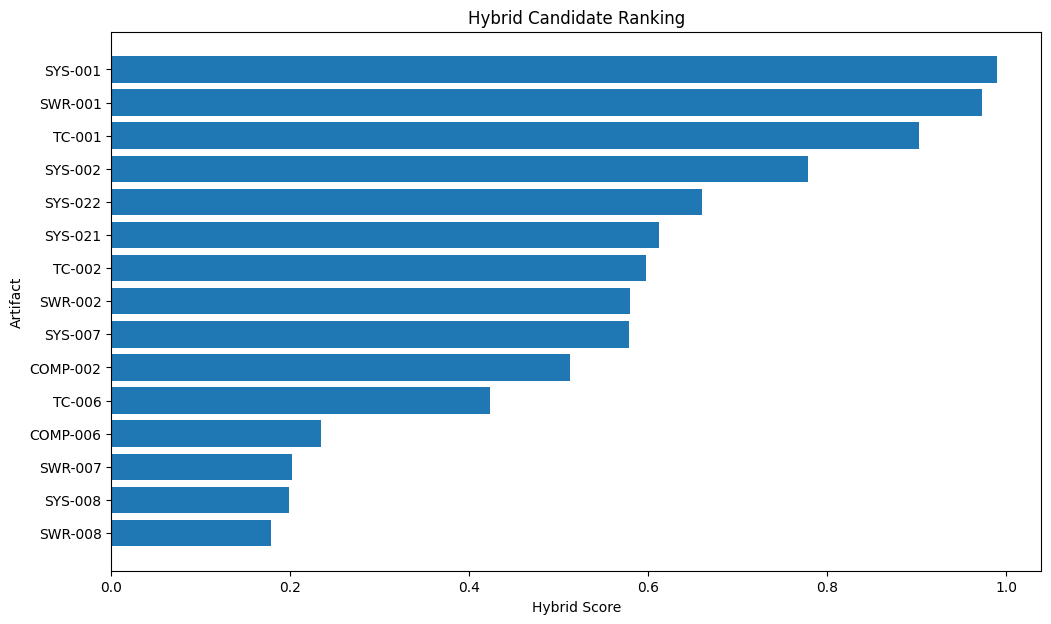

In [ ]:
import matplotlib.pyplot as plt

plot_df = hybrid_ranked.head(15).copy()

plt.figure(figsize=(12, 7))

plt.barh(
    plot_df["id"].astype(str),
    plot_df["hybrid_score"]
)

plt.xlabel("Hybrid Score")
plt.ylabel("Artifact")
plt.title("Hybrid Candidate Ranking")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
hybrid_ids = hybrid_ranked["id"].tolist()

for k in [5, 10, 15, 20]:
    result = evaluate_at_k(
        hybrid_ids,
        ground_truth_ids,
        k
    )
    print(result)

{'k': 5, 'precision': 0.8, 'recall': 0.5, 'f1': 0.6153846153846154}
{'k': 10, 'precision': 0.6, 'recall': 0.75, 'f1': 0.6666666666666665}
{'k': 15, 'precision': 0.4, 'recall': 0.75, 'f1': 0.5217391304347827}
{'k': 20, 'precision': 0.35, 'recall': 0.875, 'f1': 0.4999999999999999}


In [ ]:
k = 20

retrieved_ids = set(
    hybrid_ranked.head(k)["id"]
)

missing = ground_truth_ids - retrieved_ids

print("Ground truth IDs:")
print(sorted(ground_truth_ids))

print("\nMissing from Top-K:")
print(sorted(missing))

Ground truth IDs:
['COMP-001', 'SWR-001', 'SYS-001', 'SYS-021', 'SYS-022', 'SYS-025', 'TC-001', 'TC-002']

Missing from Top-K:
['SYS-025']


In [ ]:
for artifact_id in ["COMP-001", "SYS-025"]:

    print("=" * 80)
    print(artifact_id)

    row = change_retrieved[
        change_retrieved["id"] == artifact_id
    ]

    if len(row):
        print(
            "Retrieved:",
            True
        )
        print(
            "Similarity:",
            row.iloc[0]["similarity"]
        )
    else:
        print(
            "Retrieved:",
            False
        )

COMP-001
Retrieved: False
SYS-025
Retrieved: False


In [ ]:
import os
from google.colab import userdata
# We will use the OpenAI client as OpenRouter provides an OpenAI-compatible API
from openai import OpenAI

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")

if not OPENROUTER_API_KEY:
    raise ValueError(
        "OPENROUTER_API_KEY was not found. "
        "Add your OpenRouter API key to Colab Secrets."
    )

client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"  # OpenRouter base URL
)

print("OpenRouter client initialized via OpenAI library.")

OpenRouter client initialized via OpenAI library.


In [ ]:
# Using a model available on OpenRouter, for example, google/gemini-pro
MODEL = "nvidia/nemotron-3.5-lightning:free"

print("Model:", MODEL)

Model: nvidia/nemotron-3.5-lightning:free


In [ ]:
from pydantic import BaseModel
from typing import Literal


class ImpactAssessment(BaseModel):
    artifact_id: str

    impact_level: Literal[
        "DIRECT",
        "POTENTIAL",
        "NO_IMPACT"
    ]

    confidence: float

    reason: str

    evidence: list[str]


class ImpactAnalysisResponse(BaseModel):
    assessments: list[ImpactAssessment]

In [ ]:
SYSTEM_PROMPT = """
You are an automotive Change Impact Analysis classifier.

Classify every candidate artifact into exactly one:

DIRECT
POTENTIAL
NO_IMPACT

DIRECT:
The artifact explicitly contains or verifies the behavior/parameter
that changed.

POTENTIAL:
The artifact is functionally related to the changed behavior,
but direct impact is not proven.

NO_IMPACT:
There is sufficient evidence that the artifact is unrelated.

Rules:
- Use the artifact text and traceability evidence.
- Do not use semantic similarity alone.
- Do not invent relationships.
- Consider the OLD and NEW requirements.
- Return exactly one result for every candidate.
- Do NOT provide reasoning or analysis outside the JSON.
- Keep the reason to ONE short sentence.
- Keep evidence to ONE short sentence.

Return ONLY valid JSON in this exact format:

{
  "assessments": [
    {
      "artifact_id": "SYS-001",
      "impact_level": "DIRECT",
      "confidence": 0.95,
      "reason": "Short reason.",
      "evidence": ["Short evidence."]
    }
  ]
}
"""

In [ ]:
class ImpactAssessment(BaseModel):
    artifact_id: str
    impact_level: Literal[
        "DIRECT",
        "POTENTIAL",
        "NO_IMPACT"
    ]
    confidence: float
    reason: str
    evidence: list[str]


class ImpactAnalysisResponse(BaseModel):
    assessments: list[ImpactAssessment]

In [ ]:
response_format = {
    "type": "json_schema",
    "json_schema": {
        "name": "impact_analysis",
        "description": "Engineering change impact analysis results",
        "schema": ImpactAnalysisResponse.model_json_schema(),
        "strict": True,
    },
}

In [ ]:
import pandas as pd
import numpy as np


def safe_value(value):

    if pd.isna(value):
        return None

    if isinstance(value, (np.integer, np.floating)):
        return value.item()

    return value

In [ ]:
def build_llm_context(
    change_id,
    requirement_id,
    old_text,
    new_text,
    ranked_candidates
):

    context = f"""
CHANGE REQUEST
-------------
Change ID: {change_id}

Changed Requirement ID:
{requirement_id}

OLD REQUIREMENT:
{old_text}

NEW REQUIREMENT:
{new_text}


CANDIDATE ARTIFACTS
-------------------
"""

    for _, row in ranked_candidates.iterrows():

        artifact_id = safe_value(row.get("id"))
        artifact_type = safe_value(row.get("type"))
        artifact_text = safe_value(row.get("text"))

        semantic_similarity = safe_value(
            row.get("semantic_similarity")
        )

        reranker_score = safe_value(
            row.get("reranker")
        )

        if reranker_score is None:
            reranker_score = safe_value(
                row.get("reranker_score")
            )

        graph_linked = safe_value(
            row.get("graph_linked")
        )

        graph_distance = safe_value(
            row.get("graph_distance")
        )

        context += f"""

----------------------------------------
Artifact ID:
{artifact_id}

Type:
{artifact_type}

Text:
{artifact_text}

Semantic Similarity:
{semantic_similarity}

Reranker Score:
{reranker_score}

Graph Linked:
{graph_linked}

Graph Distance:
{graph_distance}
"""

    return context

In [ ]:
print(changes.columns.tolist())
display(changes.head())

['change_id', 'change_type', 'new_text', 'new_version', 'old_text', 'old_version', 'reason', 'requirement_id']


,change_id,change_type,new_text,new_version,old_text,old_version,reason,requirement_id
0,CR-001,parameter_change,The vehicle shall detect obstacles within 3 me...,2,The vehicle shall detect obstacles within 2 me...,1,Customer increased obstacle detection range.,SR-001
1,CR-002,threshold_change,The vehicle shall automatically activate the h...,2,The vehicle shall automatically activate the h...,1,New lighting specification requires activation...,SR-002
2,CR-003,timing_constraint_change,The driver warning function shall issue an aud...,2,The driver warning function shall issue an aud...,1,Driver warning response time tightened.,SR-005
3,CR-004,threshold_change,The battery monitoring function shall detect c...,2,The battery monitoring function shall detect c...,1,Battery diagnostic sensitivity increased.,SR-008
4,CR-005,timing_constraint_change,The vehicle shall detect an open door within 5...,2,The vehicle shall detect an open door within 1...,1,Door event response time tightened.,SR-009


In [ ]:
change_row = changes[
    changes["change_id"] == "CR-001"
].iloc[0]

change_id = change_row["change_id"]
requirement_id = change_row["requirement_id"]
old_text = change_row["old_text"]
new_text = change_row["new_text"]

print("Change:", change_id)
print("Requirement:", requirement_id)

print("\nOLD:")
print(old_text)

print("\nNEW:")
print(new_text)

Change: CR-001
Requirement: SR-001

OLD:
The vehicle shall detect obstacles within 2 meters.

NEW:
The vehicle shall detect obstacles within 3 meters.


In [ ]:
TOP_K_LLM = 10

llm_candidates = (
    hybrid_ranked
    .head(TOP_K_LLM)
    .copy()
)

print(f"Selected {len(llm_candidates)} candidates.")

display(
    llm_candidates[
        [
            "id",
            "type",
            "semantic_similarity"
        ]
    ]
)

Selected 10 candidates.


,id,type,semantic_similarity
0,SYS-001,system_requirement,0.675158
1,SWR-001,software_requirement,0.686427
2,TC-001,test_case,0.645372
3,SYS-002,system_requirement,0.595509
4,SYS-022,system_requirement,0.541823
5,SYS-021,system_requirement,0.505180
6,TC-002,test_case,0.502774
7,SWR-002,software_requirement,0.549519
8,SYS-007,system_requirement,0.622161
9,COMP-002,component,0.535015


In [ ]:
print(hybrid_ranked.columns.tolist())

['id', 'type', 'text', 'semantic_similarity', 'graph_linked', 'paths', 'graph_distance', 'reranker_score', 'graph_linked_numeric', 'semantic_score_norm', 'reranker_score_norm', 'hybrid_score']


In [ ]:
user_prompt = build_llm_context(
    change_id=change_id,
    requirement_id=requirement_id,
    old_text=old_text,
    new_text=new_text,
    ranked_candidates=llm_candidates
)

print(user_prompt)


CHANGE REQUEST
-------------
Change ID: CR-001

Changed Requirement ID:
SR-001

OLD REQUIREMENT:
The vehicle shall detect obstacles within 2 meters.

NEW REQUIREMENT:
The vehicle shall detect obstacles within 3 meters.


CANDIDATE ARTIFACTS
-------------------


----------------------------------------
Artifact ID:
SYS-001

Type:
system_requirement

Text:
The obstacle detection system shall detect objects at distances up to 2 meters.

Semantic Similarity:
0.6751578450202942

Reranker Score:
1.8994001150131226

Graph Linked:
True

Graph Distance:
1.0


----------------------------------------
Artifact ID:
SWR-001

Type:
software_requirement

Text:
The obstacle detector shall classify an obstacle as detected when distance <= 2 meters.

Semantic Similarity:
0.6864265203475952

Reranker Score:
1.4678800106048584

Graph Linked:
True

Graph Distance:
2.0


----------------------------------------
Artifact ID:
TC-001

Type:
test_case

Text:
Verify obstacle detection at 2 meters.

Semantic Si

In [ ]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ],
    response_format=response_format,
    temperature=0.0,
)

raw_output = response.choices[0].message.content

print(raw_output)

{
  "assessments": [
    {
      "artifact_id": "SYS-001",
      "impact_level": "DIRECT",
      "confidence": 0.98,
      "reason": "Explicitly specifies the 2-meter detection range being changed.",
      "evidence": ["Text states 'up to 2 meters'."]
    },
    {
      "artifact_id": "SWR-001",
      "impact_level": "DIRECT",
      "confidence": 0.97,
      "reason": "Directly uses <= 2 meters as the detection threshold parameter.",
      "evidence": ["Text states 'distance <= 2 meters'."]
    },
    {
      "artifact_id": "TC-001",
      "impact_level": "DIRECT",
      "confidence": 0.95,
      "reason": "Test case specifically validates detection at the 2-meter boundary.",
      "evidence": ["Text states 'at 2 meters'."]
    },
    {
      "artifact_id": "SYS-002",
      "impact_level": "NO_IMPACT",
      "confidence": 0.93,
      "reason": "Artifact describes publishing measurements without referencing detection range threshold.",
      "evidence": ["Text does not mention 2 meters 

In [ ]:
print("RAW OUTPUT:")
print(repr(raw_output))

RAW OUTPUT:
'{\n  "assessments": [\n    {\n      "artifact_id": "SYS-001",\n      "impact_level": "DIRECT",\n      "confidence": 0.98,\n      "reason": "Explicitly specifies the 2-meter detection range being changed.",\n      "evidence": ["Text states \'up to 2 meters\'."]\n    },\n    {\n      "artifact_id": "SWR-001",\n      "impact_level": "DIRECT",\n      "confidence": 0.97,\n      "reason": "Directly uses <= 2 meters as the detection threshold parameter.",\n      "evidence": ["Text states \'distance <= 2 meters\'."]\n    },\n    {\n      "artifact_id": "TC-001",\n      "impact_level": "DIRECT",\n      "confidence": 0.95,\n      "reason": "Test case specifically validates detection at the 2-meter boundary.",\n      "evidence": ["Text states \'at 2 meters\'."]\n    },\n    {\n      "artifact_id": "SYS-002",\n      "impact_level": "NO_IMPACT",\n      "confidence": 0.93,\n      "reason": "Artifact describes publishing measurements without referencing detection range threshold.",\n    

In [ ]:
print("TYPE:", type(raw_output))
print("LENGTH:", len(raw_output) if raw_output else 0)

TYPE: <class 'str'>
LENGTH: 11299


In [ ]:
import json
import re


def extract_json(text):

    if not text:
        raise ValueError("LLM returned an empty response.")

    text = text.strip()

    # Remove markdown code fences
    text = re.sub(
        r"```json\s*",
        "",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"```\s*",
        "",
        text
    )

    text = text.strip()

    # Try direct JSON parsing first
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # Find the first JSON object in the response
    start = text.find("{")
    end = text.rfind("}")

    if start != -1 and end != -1 and end > start:

        json_text = text[start:end + 1]

        try:
            return json.loads(json_text)
        except json.JSONDecodeError as e:
            print("Found JSON-like content but it is malformed.")
            print("\nExtracted content:\n")
            print(json_text)
            raise e

    raise ValueError(
        "No JSON object found in the LLM response.\n\n"
        f"Raw output:\n{text}"
    )

In [ ]:
parsed_output = extract_json(raw_output)

print(
    json.dumps(
        parsed_output,
        indent=2
    )
)

{
  "assessments": [
    {
      "artifact_id": "SYS-001",
      "impact_level": "DIRECT",
      "confidence": 0.98,
      "reason": "Explicitly specifies the 2-meter detection range being changed.",
      "evidence": [
        "Text states 'up to 2 meters'."
      ]
    },
    {
      "artifact_id": "SWR-001",
      "impact_level": "DIRECT",
      "confidence": 0.97,
      "reason": "Directly uses <= 2 meters as the detection threshold parameter.",
      "evidence": [
        "Text states 'distance <= 2 meters'."
      ]
    },
    {
      "artifact_id": "TC-001",
      "impact_level": "DIRECT",
      "confidence": 0.95,
      "reason": "Test case specifically validates detection at the 2-meter boundary.",
      "evidence": [
        "Text states 'at 2 meters'."
      ]
    },
    {
      "artifact_id": "SYS-002",
      "impact_level": "NO_IMPACT",
      "confidence": 0.93,
      "reason": "Artifact describes publishing measurements without referencing detection range threshold.",
   

In [ ]:
llm_result = ImpactAnalysisResponse.model_validate(
    parsed_output
)

print(
    f"Received {len(llm_result.assessments)} assessments."
)

Received 10 assessments.


In [ ]:
for assessment in llm_result.assessments:

    print("=" * 90)

    print(
        f"{assessment.artifact_id} | "
        f"{assessment.impact_level} | "
        f"confidence={assessment.confidence:.2f}"
    )

    print("\nReason:")
    print(assessment.reason)

    print("\nEvidence:")

    for evidence in assessment.evidence:
        print(f"  • {evidence}")

SYS-001 | DIRECT | confidence=0.98

Reason:
Explicitly specifies the 2-meter detection range being changed.

Evidence:
  • Text states 'up to 2 meters'.
SWR-001 | DIRECT | confidence=0.97

Reason:
Directly uses <= 2 meters as the detection threshold parameter.

Evidence:
  • Text states 'distance <= 2 meters'.
TC-001 | DIRECT | confidence=0.95

Reason:
Test case specifically validates detection at the 2-meter boundary.

Evidence:
  • Text states 'at 2 meters'.
SYS-002 | NO_IMPACT | confidence=0.93

Reason:
Artifact describes publishing measurements without referencing detection range threshold.

Evidence:
  • Text does not mention 2 meters or 3 meters.
SYS-022 | NO_IMPACT | confidence=0.93

Reason:
Artifact focuses on sensor quality flag rejection, unrelated to range threshold.

Evidence:
  • Text does not mention detection range.
SYS-021 | NO_IMPACT | confidence=0.93

Reason:
Artifact specifies processing frequency, not detection range.

Evidence:
  • Text states 'at 20 Hz'.
TC-002 | 

In [ ]:
impact_results = pd.DataFrame([
    {
        "artifact_id": assessment.artifact_id,
        "impact_level": assessment.impact_level,
        "confidence": assessment.confidence,
        "reason": assessment.reason,
        "evidence": " | ".join(
            assessment.evidence
        )
    }
    for assessment in llm_result.assessments
])

display(impact_results)

,artifact_id,impact_level,confidence,reason,evidence
0,SYS-001,DIRECT,0.98,Explicitly specifies the 2-meter detection ran...,Text states 'up to 2 meters'.
1,SWR-001,DIRECT,0.97,Directly uses <= 2 meters as the detection thr...,Text states 'distance <= 2 meters'.
2,TC-001,DIRECT,0.95,Test case specifically validates detection at ...,Text states 'at 2 meters'.
3,SYS-002,NO_IMPACT,0.93,Artifact describes publishing measurements wit...,Text does not mention 2 meters or 3 meters.
4,SYS-022,NO_IMPACT,0.93,Artifact focuses on sensor quality flag reject...,Text does not mention detection range.
5,SYS-021,NO_IMPACT,0.93,"Artifact specifies processing frequency, not d...",Text states 'at 20 Hz'.
6,TC-002,DIRECT,0.94,Test case explicitly verifies behavior relativ...,Text states 'beyond the configured detection r...
7,SWR-002,NO_IMPACT,0.92,Artifact describes publishing obstacle measure...,Text does not mention 2 meters or 3 meters.
8,SYS-007,NO_IMPACT,0.94,Different system (parking assistance) with dis...,Text specifies 1.5 meters for parking assistan...
9,COMP-002,NO_IMPACT,0.92,Component publishes obstacle measurements with...,Text does not reference 2 meters or 3 meters.


In [ ]:
candidate_ids = set(
    llm_candidates["id"].astype(str)
)

assessment_ids = set(
    impact_results["artifact_id"].astype(str)
)

print("Candidates:", len(candidate_ids))
print("Assessments:", len(assessment_ids))

print(
    "\nMissing assessments:"
)

print(
    candidate_ids - assessment_ids
)

print(
    "\nUnexpected artifacts:"
)

print(
    assessment_ids - candidate_ids
)

Candidates: 10
Assessments: 10

Missing assessments:
set()

Unexpected artifacts:
set()


In [ ]:
impact_summary = (
    impact_results["impact_level"]
    .value_counts()
    .to_dict()
)

print("Impact Summary")
print("-" * 40)

for level in [
    "DIRECT",
    "POTENTIAL",
    "NO_IMPACT"
]:

    print(
        f"{level}: "
        f"{impact_summary.get(level, 0)}"
    )

Impact Summary
----------------------------------------
DIRECT: 4
POTENTIAL: 0
NO_IMPACT: 6
